In [40]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [28]:
# ── The exact same 4×4 input image from our hand calculation ──────────
x = torch.tensor([[2., 1., 0., 3.],
                   [1., 0., 2., 1.],
                   [3., 2., 1., 0.],
                   [0., 1., 3., 2.]])

# PyTorch conv layers expect input shape: (batch, channels, height, width)
x = x.unsqueeze(0).unsqueeze(0)   # shape becomes (1, 1, 4, 4)



In [29]:
# ── Convolution layer: 1 input channel, 2 output channels (our 2 filters), 3×3 kernel ──
conv = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=3, stride=1, padding=0, bias=False)

# Manually set the weights to match Filter A and Filter B exactly
with torch.no_grad():
    conv.weight[0, 0] = torch.tensor([[1., 0., -1.],
                                       [1., 0., -1.],
                                       [1., 0., -1.]])   # Filter A
    conv.weight[1, 0] = torch.tensor([[1.,  1.,  1.],
                                       [0.,  0.,  0.],
                                       [-1., -1., -1.]]) # Filter B

conv_out = conv(x)
print("Conv output shape:", conv_out.shape)   # expect (1, 2, 2, 2)
print("Conv output:\n", conv_out)


Conv output shape: torch.Size([1, 2, 2, 2])
Conv output:
 tensor([[[[ 3., -1.],
          [-2.,  0.]],

         [[-3.,  1.],
          [-1., -3.]]]], grad_fn=<ConvolutionBackward0>)


In [30]:
# ── ReLU ────────────────────────────────────────────────────────────
relu = nn.ReLU()
relu_out = relu(conv_out)
print("\nReLU output:\n", relu_out)

# ── Max pooling: 2×2 window, stride 2 ───────────────────────────────
pool = nn.MaxPool2d(kernel_size=2, stride=2)
pool_out = pool(relu_out)
print("\nPooled output:\n", pool_out)

# ── Flatten ──────────────────────────────────────────────────────────
flatten = nn.Flatten()
flat_out = flatten(pool_out)
print("\nFlattened vector:", flat_out)


ReLU output:
 tensor([[[[3., 0.],
          [0., 0.]],

         [[0., 1.],
          [0., 0.]]]], grad_fn=<ReluBackward0>)

Pooled output:
 tensor([[[[3.]],

         [[1.]]]], grad_fn=<MaxPool2DWithIndicesBackward0>)

Flattened vector: tensor([[3., 1.]], grad_fn=<ViewBackward0>)


In [31]:
# ── Fully-connected layer: 2 inputs → 1 output ──────────────────────
fc = nn.Linear(in_features=2, out_features=1)

with torch.no_grad():
    fc.weight[0] = torch.tensor([0.5, -1.0])
    fc.bias[0] = 0.2

z = fc(flat_out)
print("\nz (pre-activation):", z)

# ── Sigmoid ──────────────────────────────────────────────────────────
sigmoid = nn.Sigmoid()
y_hat = sigmoid(z)
print("Final prediction (ŷ):", y_hat)


z (pre-activation): tensor([[0.7000]], grad_fn=<AddmmBackward0>)
Final prediction (ŷ): tensor([[0.6682]], grad_fn=<SigmoidBackward0>)


In [32]:
class ToyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=3, stride=1, padding=0)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(in_features=2, out_features=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.conv(x)      # 4×4×1 → 2×2×2
        x = self.relu(x)      # element-wise, shape unchanged
        x = self.pool(x)      # 2×2×2 → 1×1×2
        x = self.flatten(x)   # 1×1×2 → 2  (a flat vector)
        x = self.fc(x)        # 2 → 1
        x = self.sigmoid(x)
        return x

In [33]:
"""  
Input:        (1, 1, 4, 4)
After conv:   (1, 2, 2, 2)   ← matches your two 2x2 feature maps
After relu:   (1, 2, 2, 2)   ← unchanged shape, values zeroed where negative
After pool:   (1, 2, 1, 1)   ← matches your two pooled scalars, 3 and 1
After flatten:(1, 2)          ← matches your [3, 1] vector
After fc:     (1, 1)          ← matches your z = 0.7
After sigmoid:(1, 1)          ← matches your ŷ = 0.6682
"""

'  \nInput:        (1, 1, 4, 4)\nAfter conv:   (1, 2, 2, 2)   ← matches your two 2x2 feature maps\nAfter relu:   (1, 2, 2, 2)   ← unchanged shape, values zeroed where negative\nAfter pool:   (1, 2, 1, 1)   ← matches your two pooled scalars, 3 and 1\nAfter flatten:(1, 2)          ← matches your [3, 1] vector\nAfter fc:     (1, 1)          ← matches your z = 0.7\nAfter sigmoid:(1, 1)          ← matches your ŷ = 0.6682\n'

In [34]:
model = ToyCNN()

x = torch.tensor([[2., 1., 0., 3.],
                   [1., 0., 2., 1.],
                   [3., 2., 1., 0.],
                   [0., 1., 3., 2.]])

x = x.unsqueeze(0).unsqueeze(0)   # (4,4) → (1,1,4,4): batch=1, channels=1
print("Input shape:", x.shape)

output = model(x)
print("Output shape:", output.shape)
print("Output value:", output)

Input shape: torch.Size([1, 1, 4, 4])
Output shape: torch.Size([1, 1])
Output value: tensor([[0.7324]], grad_fn=<SigmoidBackward0>)


In [35]:
criterion = nn.BCELoss()   # binary cross-entropy, since our sigmoid output is a probability
optimizer = optim.Adam(model.parameters(), lr=0.01)

y_true = torch.tensor([[1.0]])

loss_values = []

for epoch in range(1,51):
    optimizer.zero_grad()
    y_pred = model(x)
    loss = criterion(y_pred, y_true)
    loss.backward()
    optimizer.step()
    loss_values.append(np.around(loss.item(),4))
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 0.1111
Epoch 20, Loss: 0.0343
Epoch 30, Loss: 0.0138
Epoch 40, Loss: 0.0075
Epoch 50, Loss: 0.0051


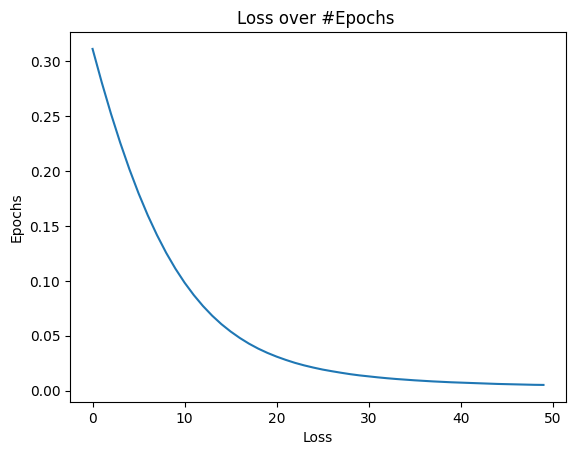

In [43]:
plt.plot(pd.DataFrame({'loss':loss_values}))
plt.xlabel('Loss')
plt.ylabel('Epochs')
plt.title('Loss over #Epochs ')
plt.show()